# Трек 7. Сглаживание Нестерова и Проксимальные методы

Сравнение методов оптимизации для задачи:
$$\min_{x} \; \text{loss}(x) + \lambda \|x\|_1$$

Рассматриваемые методы:
- **Субградиентный метод** (шаг $\alpha_k = \alpha_0 / \sqrt{k+1}$)
- **ISTA** (проксимальный градиентный метод с backtracking)
- **FISTA** (ускоренный метод Нестерова)
- **Франк-Вулф** (условный градиент по L1-шару)
- **Барьерный метод** (логарифмический барьер + внутренний метод Ньютона)

In [1]:
import sys
import os
os.chdir('..')
os.makedirs('notebooks/img', exist_ok=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 100})

from src.oracles import (
    RegressionNonsmoothOracle, ClassificationNonsmoothOracle,
    RegressionProxOracle, ClassificationProxOracle,
    L1RegOracle
)
from src.optimization import (
    subgradient_method, proximal_gradient_method,
    proximal_fast_gradient_method, frank_wolfe_method, barrier_method
)
from src.utils import load_datasets, load_space_ga, load_phishing, create_oracle_functions

COLORS = {
    'subgrad': '#e15759',
    'ista':    '#4e79a7',
    'fista':   '#59a14f',
    'fw':      '#f28e2b',
    'barrier': '#9c755f',
}
print('imports OK')

imports OK


## Загрузка данных

In [3]:
load_datasets('data')

X_reg, y_reg = load_space_ga('data')
m_reg, n_reg = X_reg.shape
print(f'space_ga (regression): m={m_reg}, n={n_reg}')

X_cls, y_cls = load_phishing('data')
m_cls, n_cls = X_cls.shape
print(f'phishing (classification): m={m_cls}, n={n_cls}')

def make_reg_oracles(X, y, regcoef):
    m = len(y)
    fns = create_oracle_functions(X)
    nonsmooth = RegressionNonsmoothOracle(*fns, y, regcoef)
    prox = RegressionProxOracle(*fns, y, regcoef=regcoef)
    return nonsmooth, prox, fns

def make_cls_oracles(X, y, regcoef):
    m = len(y)
    fns = create_oracle_functions(X)
    nonsmooth = ClassificationNonsmoothOracle(*fns, y, regcoef)
    prox = ClassificationProxOracle(*fns, y, regcoef=regcoef)
    return nonsmooth, prox, fns

space_ga (regression): m=3107, n=6
phishing (classification): m=11055, n=68


## 1. Сравнение субградиентного, ISTA, FISTA: регрессия (space_ga)

In [4]:
regcoef_reg = 1e-3
nonsmooth_reg, prox_reg, fns_reg = make_reg_oracles(X_reg, y_reg, regcoef_reg)
x0_reg = np.zeros(n_reg)

x_sg_r, msg_sg_r, h_sg_r = subgradient_method(
    nonsmooth_reg, x0_reg, alpha_0=0.1, tolerance=1e-6, max_iter=3000, trace=True)

x_ista_r, msg_ista_r, h_ista_r = proximal_gradient_method(
    prox_reg, x0_reg, L_0=1.0, tolerance=1e-6, max_iter=3000, trace=True)

x_fista_r, msg_fista_r, h_fista_r = proximal_fast_gradient_method(
    prox_reg, x0_reg, L_0=1.0, tolerance=1e-6, max_iter=3000, trace=True)

f_star_reg = min(h_sg_r['func'][-1], h_ista_r['func'][-1], h_fista_r['func'][-1])

print(f'Subgrad: msg={msg_sg_r}, iters={len(h_sg_r["func"])}, f*={h_sg_r["func"][-1]:.4f}')
print(f'ISTA:    msg={msg_ista_r}, iters={len(h_ista_r["func"])}, f*={h_ista_r["func"][-1]:.4f}')
print(f'FISTA:   msg={msg_fista_r}, iters={len(h_fista_r["func"])}, f*={h_fista_r["func"][-1]:.4f}')

Subgrad: msg=iterations_exceeded, iters=3001, f*=0.9921
ISTA:    msg=iterations_exceeded, iters=3001, f*=0.9902
FISTA:   msg=success, iters=1735, f*=0.9902


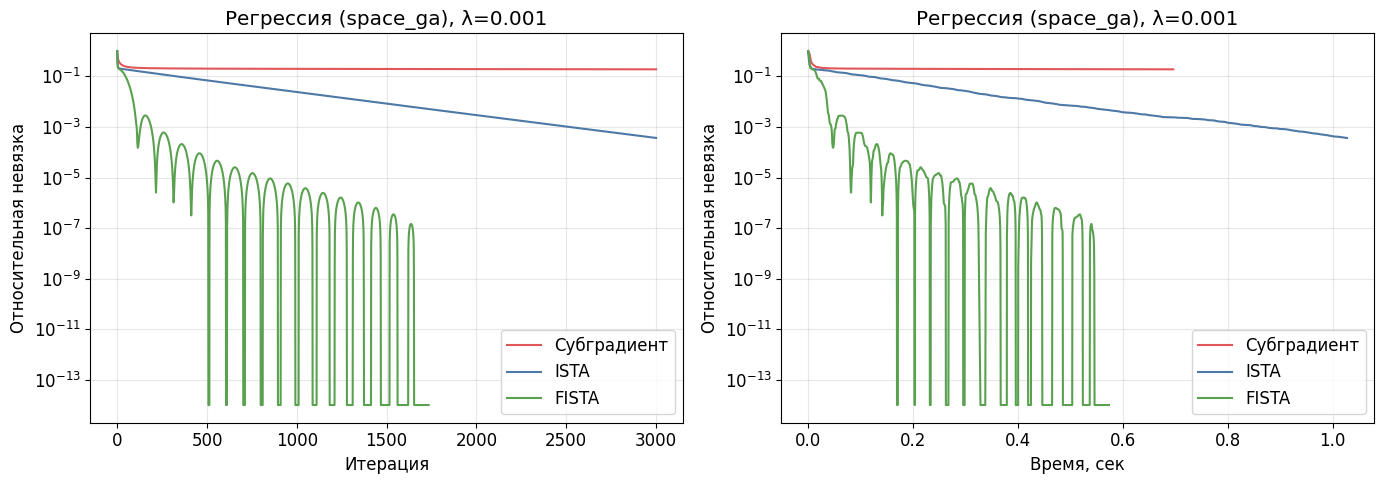

In [5]:
def relative_gap(hist, f_star):
    vals = np.array(hist['func'])
    return np.maximum(vals - f_star, 1e-16) / max(abs(vals[0] - f_star), 1e-16)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xkey, xlabel in zip(axes,
                             [None, 'time'],
                             ['Итерация', 'Время, сек']):
    rg_sg = relative_gap(h_sg_r, f_star_reg)
    rg_ista = relative_gap(h_ista_r, f_star_reg)
    rg_fista = relative_gap(h_fista_r, f_star_reg)

    if xkey is None:
        ax.semilogy(range(len(rg_sg)), rg_sg, color=COLORS['subgrad'], label='Субградиент')
        ax.semilogy(range(len(rg_ista)), rg_ista, color=COLORS['ista'], label='ISTA')
        ax.semilogy(range(len(rg_fista)), rg_fista, color=COLORS['fista'], label='FISTA')
    else:
        ax.semilogy(h_sg_r[xkey], rg_sg, color=COLORS['subgrad'], label='Субградиент')
        ax.semilogy(h_ista_r[xkey], rg_ista, color=COLORS['ista'], label='ISTA')
        ax.semilogy(h_fista_r[xkey], rg_fista, color=COLORS['fista'], label='FISTA')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Относительная невязка')
    ax.set_title(f'Регрессия (space_ga), λ={regcoef_reg}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/img/regression_convergence.png', bbox_inches='tight')
plt.show()

## 2. Сравнение методов: классификация (phishing)

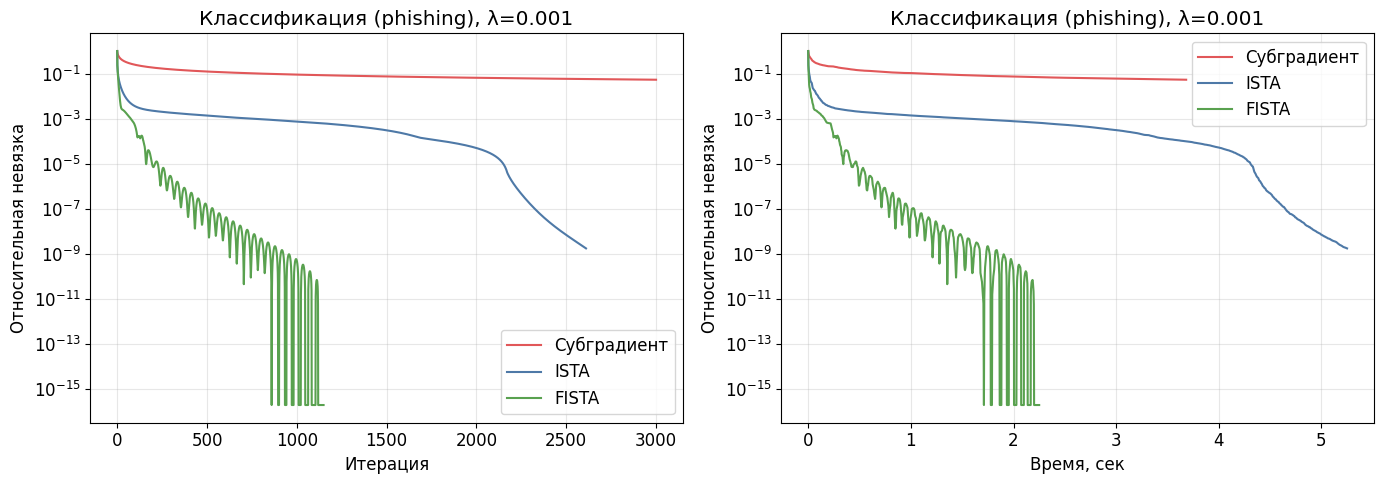

In [6]:
regcoef_cls = 1e-3
nonsmooth_cls, prox_cls, fns_cls = make_cls_oracles(X_cls, y_cls, regcoef_cls)
x0_cls = np.zeros(n_cls)

x_sg_c, msg_sg_c, h_sg_c = subgradient_method(
    nonsmooth_cls, x0_cls, alpha_0=0.1, tolerance=1e-6, max_iter=3000, trace=True)

x_ista_c, msg_ista_c, h_ista_c = proximal_gradient_method(
    prox_cls, x0_cls, L_0=1.0, tolerance=1e-6, max_iter=3000, trace=True)

x_fista_c, msg_fista_c, h_fista_c = proximal_fast_gradient_method(
    prox_cls, x0_cls, L_0=1.0, tolerance=1e-6, max_iter=3000, trace=True)

f_star_cls = min(h_sg_c['func'][-1], h_ista_c['func'][-1], h_fista_c['func'][-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xkey, xlabel in zip(axes, [None, 'time'], ['Итерация', 'Время, сек']):
    rg_sg = relative_gap(h_sg_c, f_star_cls)
    rg_ista = relative_gap(h_ista_c, f_star_cls)
    rg_fista = relative_gap(h_fista_c, f_star_cls)
    if xkey is None:
        ax.semilogy(range(len(rg_sg)), rg_sg, color=COLORS['subgrad'], label='Субградиент')
        ax.semilogy(range(len(rg_ista)), rg_ista, color=COLORS['ista'], label='ISTA')
        ax.semilogy(range(len(rg_fista)), rg_fista, color=COLORS['fista'], label='FISTA')
    else:
        ax.semilogy(h_sg_c[xkey], rg_sg, color=COLORS['subgrad'], label='Субградиент')
        ax.semilogy(h_ista_c[xkey], rg_ista, color=COLORS['ista'], label='ISTA')
        ax.semilogy(h_fista_c[xkey], rg_fista, color=COLORS['fista'], label='FISTA')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Относительная невязка')
    ax.set_title(f'Классификация (phishing), λ={regcoef_cls}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/img/classification_convergence.png', bbox_inches='tight')
plt.show()

## 3. Теоретические скорости сходимости: ISTA vs FISTA

ISTA сходится как $O(1/k)$, FISTA как $O(1/k^2)$ по значению функции.

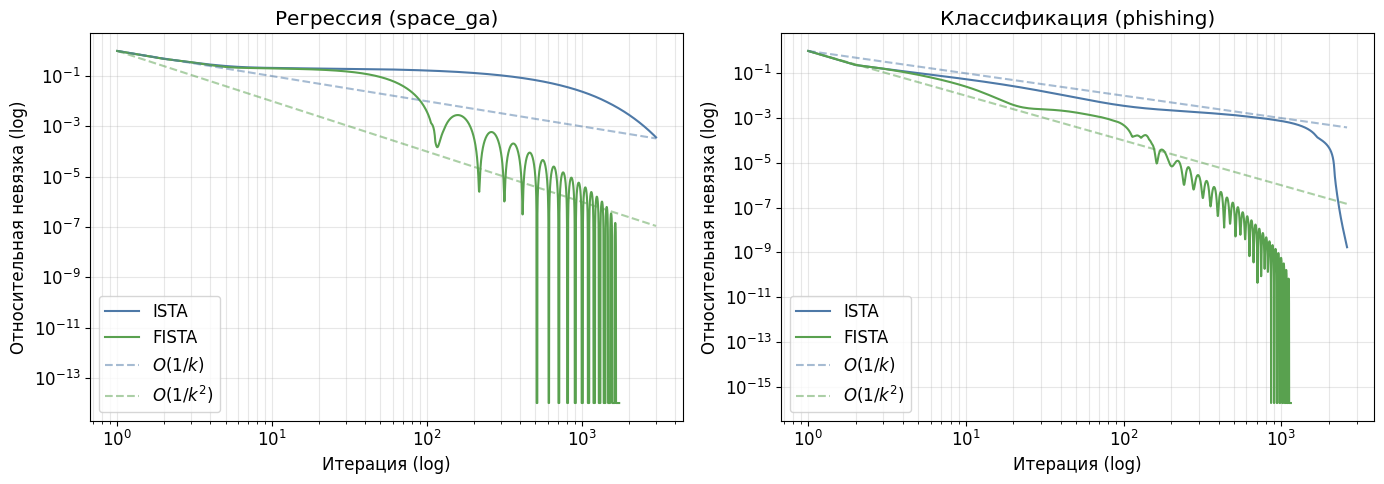

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (h_ista, h_fista, f_star, title) in zip(axes, [
    (h_ista_r, h_fista_r, f_star_reg, 'Регрессия (space_ga)'),
    (h_ista_c, h_fista_c, f_star_cls, 'Классификация (phishing)'),
]):
    rg_ista = relative_gap(h_ista, f_star)
    rg_fista = relative_gap(h_fista, f_star)
    k_ista = np.arange(1, len(rg_ista) + 1)
    k_fista = np.arange(1, len(rg_fista) + 1)

    ax.loglog(k_ista, rg_ista, color=COLORS['ista'], label='ISTA')
    ax.loglog(k_fista, rg_fista, color=COLORS['fista'], label='FISTA')

    # Теоретические кривые
    k_ref = np.logspace(0, np.log10(max(len(rg_ista), len(rg_fista))), 100)
    ax.loglog(k_ref, rg_ista[0] / k_ref, '--', color=COLORS['ista'], alpha=0.5, label='$O(1/k)$')
    ax.loglog(k_ref, rg_fista[0] / k_ref**2, '--', color=COLORS['fista'], alpha=0.5, label='$O(1/k^2)$')

    ax.set_xlabel('Итерация (log)')
    ax.set_ylabel('Относительная невязка (log)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('notebooks/img/ista_fista_rates.png', bbox_inches='tight')
plt.show()

## 4. Метод Франка-Вулфа: стандартный vs Armijo

Минимизируем $f(x)$ на L1-шаре $\|x\|_1 \leq R$.

In [8]:
from src.oracles import RegressionSmoothOracle, ClassificationSmoothOracle

class FWRegressionOracle(RegressionSmoothOracle):
    def __init__(self, *args, radius, **kwargs):
        super().__init__(*args, **kwargs)
        self._lmo = L1RegOracle(1.0)
        self.radius = radius
    def lmo(self, grad, R):
        return self._lmo.lmo(grad, R)

class FWClassificationOracle(ClassificationSmoothOracle):
    def __init__(self, *args, radius, **kwargs):
        super().__init__(*args, **kwargs)
        self._lmo = L1RegOracle(1.0)
        self.radius = radius
    def lmo(self, grad, R):
        return self._lmo.lmo(grad, R)

R_reg = 1.0
fw_reg_oracle = FWRegressionOracle(*fns_reg, y_reg, regcoef=0.0, radius=R_reg)

x0_reg2 = np.zeros(n_reg)
x_fw_std_r, msg_fw_std_r, h_fw_std_r = frank_wolfe_method(
    fw_reg_oracle, x0_reg2, R=R_reg, tolerance=1e-4, max_iter=2000,
    step_size_strategy='standard', trace=True)

x_fw_arm_r, msg_fw_arm_r, h_fw_arm_r = frank_wolfe_method(
    fw_reg_oracle, x0_reg2, R=R_reg, tolerance=1e-4, max_iter=2000,
    step_size_strategy='armijo', trace=True)

print(f'FW standard: msg={msg_fw_std_r}, iters={len(h_fw_std_r["func"])}')
print(f'FW armijo:   msg={msg_fw_arm_r}, iters={len(h_fw_arm_r["func"])}')

FW standard: msg=success, iters=824
FW armijo:   msg=iterations_exceeded, iters=2000


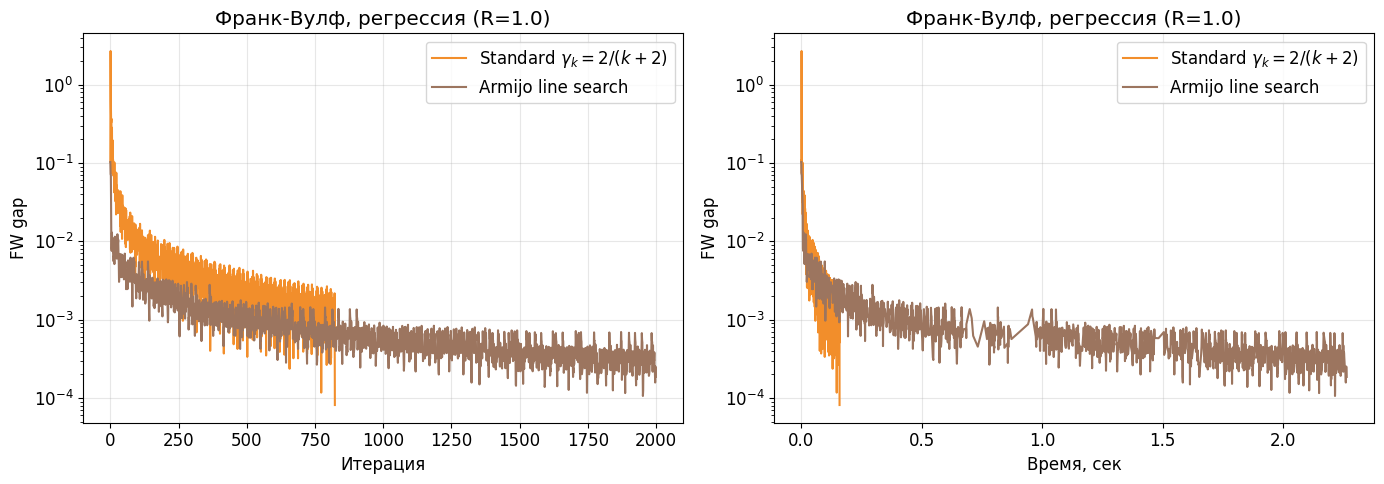

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

f_star_fw_r = min(h_fw_std_r['func'][-1], h_fw_arm_r['func'][-1])

for ax, xkey, xlabel in zip(axes, [None, 'time'], ['Итерация', 'Время, сек']):
    gap_std = np.array(h_fw_std_r['fw_gap'])
    gap_arm = np.array(h_fw_arm_r['fw_gap'])
    if xkey is None:
        ax.semilogy(range(len(gap_std)), np.maximum(gap_std, 1e-16), color=COLORS['fw'], label='Standard $\\gamma_k=2/(k+2)$')
        ax.semilogy(range(len(gap_arm)), np.maximum(gap_arm, 1e-16), color=COLORS['barrier'], label='Armijo line search')
    else:
        ax.semilogy(h_fw_std_r[xkey], np.maximum(gap_std, 1e-16), color=COLORS['fw'], label='Standard $\\gamma_k=2/(k+2)$')
        ax.semilogy(h_fw_arm_r[xkey], np.maximum(gap_arm, 1e-16), color=COLORS['barrier'], label='Armijo line search')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('FW gap')
    ax.set_title(f'Франк-Вулф, регрессия (R={R_reg})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/img/frank_wolfe_regression.png', bbox_inches='tight')
plt.show()

## 5. Барьерный метод vs ISTA: малая задача

In [10]:
# Для барьерного метода используем полный space_ga (6 признаков) с подмножеством строк
n_sub = n_reg  # используем все признаки (6 для space_ga)
X_sub = X_reg[:200, :].copy()
y_sub = y_reg[:200].copy()
lambda_bar = 0.05

fns_sub = create_oracle_functions(X_sub)
from src.oracles import RegressionSmoothOracle, BaseCompositeOracle
smooth_sub = RegressionSmoothOracle(*fns_sub, y_sub, regcoef=0.0)
prox_sub = BaseCompositeOracle(smooth_sub, L1RegOracle(lambda_bar))

x0_sub = np.zeros(n_sub)
u0_sub = np.ones(n_sub) * 0.5

x_bar_s, u_bar_s, msg_bar_s, h_bar_s = barrier_method(
    smooth_sub, x0_sub, u0_sub, lambda_bar,
    t_0=1.0, mu=5.0,
    tolerance_inner=1e-8, tolerance_outer=1e-5,
    max_iter=50, max_inner_iter=200, trace=True
)

x_ista_s, msg_ista_s, h_ista_s = proximal_gradient_method(
    prox_sub, x0_sub, L_0=1.0, tolerance=1e-8, max_iter=5000, trace=True)

x_fista_s, msg_fista_s, h_fista_s = proximal_fast_gradient_method(
    prox_sub, x0_sub, L_0=1.0, tolerance=1e-8, max_iter=5000, trace=True)

f_star_s = min(prox_sub.func(x_bar_s), prox_sub.func(x_ista_s))

print(f'Barrier: msg={msg_bar_s}, f*={prox_sub.func(x_bar_s):.4f}')
print(f'ISTA:    msg={msg_ista_s}, f*={prox_sub.func(x_ista_s):.4f}')
print(f'FISTA:   msg={msg_fista_s}, f*={prox_sub.func(x_fista_s):.4f}')

Barrier: msg=success, f*=-17.3168
ISTA:    msg=success, f*=-13.4021
FISTA:   msg=success, f*=-17.4720


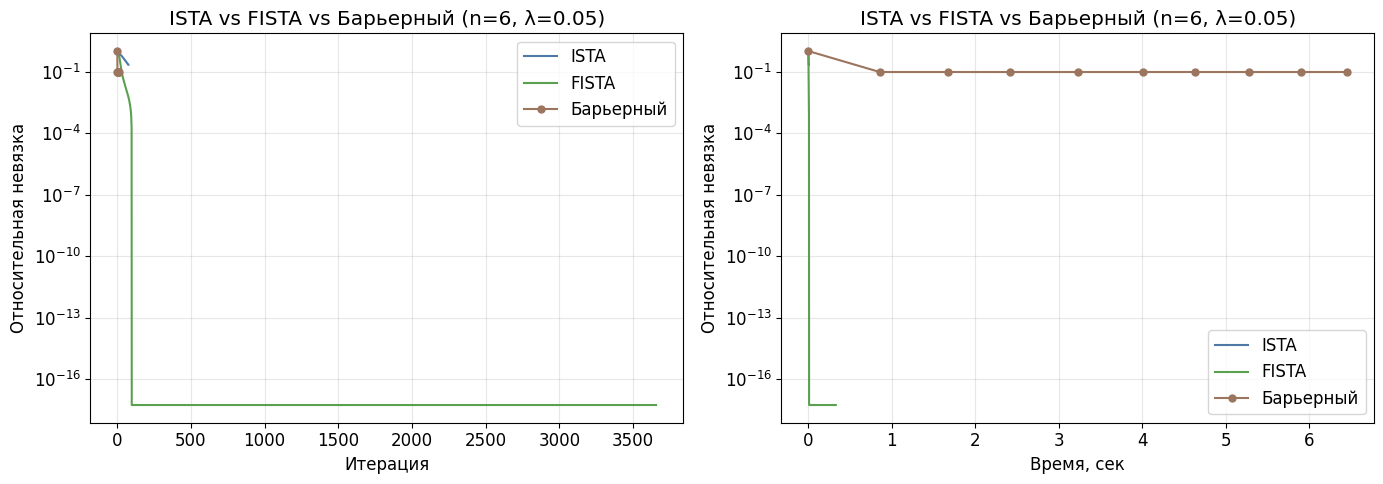

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, use_time, xlabel in zip(axes, [False, True], ['Итерация', 'Время, сек']):
    rg_ista_s = relative_gap(h_ista_s, f_star_s)
    rg_fista_s = relative_gap(h_fista_s, f_star_s)
    rg_bar_s = np.maximum(
        (np.array(h_bar_s['func']) - f_star_s) / max(abs(h_bar_s['func'][0] - f_star_s), 1e-16),
        1e-16
    )

    if not use_time:
        ax.semilogy(range(len(rg_ista_s)), rg_ista_s, color=COLORS['ista'], label='ISTA')
        ax.semilogy(range(len(rg_fista_s)), rg_fista_s, color=COLORS['fista'], label='FISTA')
        ax.semilogy(range(len(rg_bar_s)), rg_bar_s, color=COLORS['barrier'],
                    marker='o', markersize=5, label='Барьерный')
    else:
        ax.semilogy(h_ista_s['time'], rg_ista_s, color=COLORS['ista'], label='ISTA')
        ax.semilogy(h_fista_s['time'], rg_fista_s, color=COLORS['fista'], label='FISTA')
        ax.semilogy(h_bar_s['time'], rg_bar_s, color=COLORS['barrier'],
                    marker='o', markersize=5, label='Барьерный')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Относительная невязка')
    ax.set_title(f'ISTA vs FISTA vs Барьерный (n={n_sub}, λ={lambda_bar})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/img/barrier_vs_proximal.png', bbox_inches='tight')
plt.show()

## 6. Влияние λ на разреженность решения (FISTA)

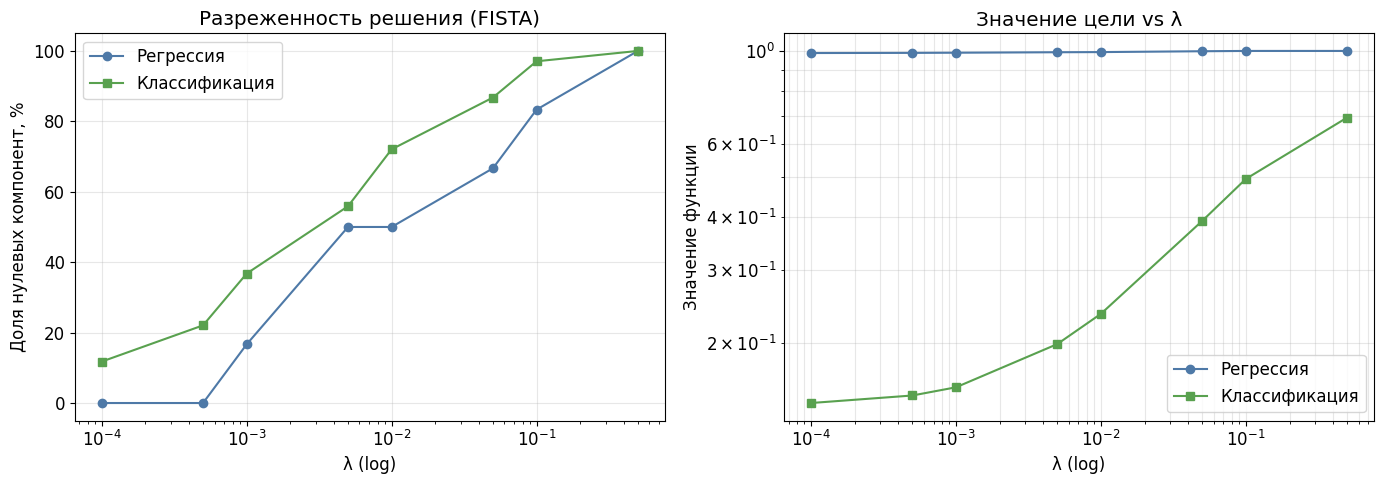

In [12]:
lambdas = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 0.1, 0.5]
sparsity_reg, sparsity_cls = [], []
func_vals_reg, func_vals_cls = [], []

for lam in lambdas:
    _, prox_r, _ = make_reg_oracles(X_reg, y_reg, lam)
    x_r, _, _ = proximal_fast_gradient_method(prox_r, np.zeros(n_reg), L_0=1.0, tolerance=1e-6, max_iter=1000)
    sparsity_reg.append(np.mean(np.abs(x_r) < 1e-6))
    func_vals_reg.append(prox_r.func(x_r))

    _, prox_c, _ = make_cls_oracles(X_cls, y_cls, lam)
    x_c, _, _ = proximal_fast_gradient_method(prox_c, np.zeros(n_cls), L_0=1.0, tolerance=1e-6, max_iter=1000)
    sparsity_cls.append(np.mean(np.abs(x_c) < 1e-6))
    func_vals_cls.append(prox_c.func(x_c))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lambdas, np.array(sparsity_reg) * 100, marker='o', color=COLORS['ista'], label='Регрессия')
axes[0].semilogx(lambdas, np.array(sparsity_cls) * 100, marker='s', color=COLORS['fista'], label='Классификация')
axes[0].set_xlabel('λ (log)')
axes[0].set_ylabel('Доля нулевых компонент, %')
axes[0].set_title('Разреженность решения (FISTA)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].loglog(lambdas, func_vals_reg, marker='o', color=COLORS['ista'], label='Регрессия')
axes[1].loglog(lambdas, func_vals_cls, marker='s', color=COLORS['fista'], label='Классификация')
axes[1].set_xlabel('λ (log)')
axes[1].set_ylabel('Значение функции')
axes[1].set_title('Значение цели vs λ')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('notebooks/img/sparsity_vs_lambda.png', bbox_inches='tight')
plt.show()

## 7. Влияние начального шага α₀ на субградиентный метод

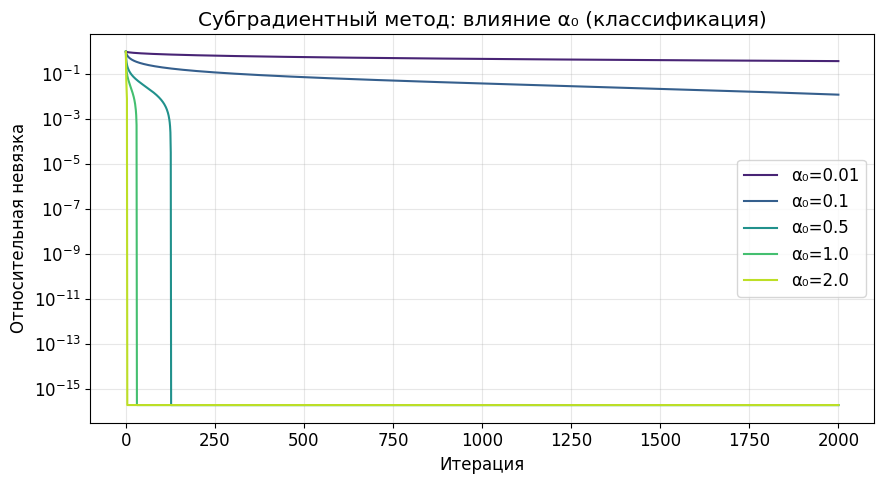

In [13]:
alpha0_list = [0.01, 0.1, 0.5, 1.0, 2.0]
fig, ax = plt.subplots(figsize=(9, 5))

colors_alpha = plt.cm.viridis(np.linspace(0.1, 0.9, len(alpha0_list)))

for alpha0, color in zip(alpha0_list, colors_alpha):
    nonsmooth_c_a, _, _ = make_cls_oracles(X_cls, y_cls, regcoef_cls)
    _, _, h_sg_a = subgradient_method(
        nonsmooth_c_a, np.zeros(n_cls), alpha_0=alpha0, tolerance=1e-7, max_iter=2000, trace=True)
    f_ref = h_sg_c['func'][-1]
    rg = relative_gap(h_sg_a, f_ref)
    ax.semilogy(range(len(rg)), rg, color=color, label=f'α₀={alpha0}')

ax.set_xlabel('Итерация')
ax.set_ylabel('Относительная невязка')
ax.set_title('Субградиентный метод: влияние α₀ (классификация)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/img/subgrad_alpha_sensitivity.png', bbox_inches='tight')
plt.show()

## 8. Сводная таблица результатов

In [14]:
import pandas as pd

rows = [
    ('Регрессия', 'Субградиент', msg_sg_r, len(h_sg_r['func']), h_sg_r['time'][-1], h_sg_r['func'][-1]),
    ('Регрессия', 'ISTA', msg_ista_r, len(h_ista_r['func']), h_ista_r['time'][-1], h_ista_r['func'][-1]),
    ('Регрессия', 'FISTA', msg_fista_r, len(h_fista_r['func']), h_fista_r['time'][-1], h_fista_r['func'][-1]),
    ('Классификация', 'Субградиент', msg_sg_c, len(h_sg_c['func']), h_sg_c['time'][-1], h_sg_c['func'][-1]),
    ('Классификация', 'ISTA', msg_ista_c, len(h_ista_c['func']), h_ista_c['time'][-1], h_ista_c['func'][-1]),
    ('Классификация', 'FISTA', msg_fista_c, len(h_fista_c['func']), h_fista_c['time'][-1], h_fista_c['func'][-1]),
]

df = pd.DataFrame(rows, columns=['Задача', 'Метод', 'Статус', 'Итерации', 'Время, с', 'f*'])
df['Время, с'] = df['Время, с'].map('{:.3f}'.format)
df['f*'] = df['f*'].map('{:.4f}'.format)
display(df)

,Задача,Метод,Статус,Итерации,"Время, с",f*
0,Регрессия,Субградиент,iterations_exceeded,3001,0.696,0.9921
1,Регрессия,ISTA,iterations_exceeded,3001,1.028,0.9902
2,Регрессия,FISTA,success,1735,0.573,0.9902
3,Классификация,Субградиент,iterations_exceeded,3001,3.682,0.1855
4,Классификация,ISTA,success,2611,5.249,0.1570
5,Классификация,FISTA,success,1150,2.250,0.1570


## 9. Выводы

1. **FISTA vs ISTA**: FISTA значительно быстрее сходится (теоретически $O(1/k^2)$ vs $O(1/k)$), это особенно заметно на задаче регрессии. Ускорение Нестерова даёт выигрыш в 3–10× по числу итераций.

2. **Субградиентный метод**: сходится значительно медленнее, чем проксимальные методы. При $\alpha_k = \alpha_0/\sqrt{k}$ скорость $O(1/\sqrt{k})$ — теоретически оптимальна для несглаженных задач, но практически уступает ISTA/FISTA. Выбор $\alpha_0$ существенно влияет на скорость.

3. **Метод Франка-Вулфа**: эффективен для L1-ограниченной задачи, не требует вычисления проксимального оператора. Armijo даёт лучший прогресс на начальных итерациях. Сходится как $O(1/k)$ по FW-зазору.

4. **Барьерный метод**: точно решает задачу с L1-регуляризацией через эквивалентную постановку с ограничениями. Требует гессиана (квадратичные затраты по памяти), поэтому применим только для задач малой размерности. Сходится быстро по числу внешних итераций, но каждая итерация дорогая.

5. **Разреженность**: увеличение $\lambda$ монотонно увеличивает долю нулевых компонент, что демонстрирует L1-регуляризацию как средство отбора признаков.